<a href="https://colab.research.google.com/github/dokunoale/chagas/blob/prova/test_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduzione
Carichiamo tutto il necessario:
- il progetto GitHub
- le librerie utili
- il file zip del dataset da Google Drive, di cui facciamo l'unzip

In [1]:
!git clone --branch dev --single-branch https://github.com/dokunoale/chagas.git
!pip install wfdb
!pip install -q gdown
from google.colab import drive
drive.mount('/content/drive')

import gdown
import numpy as np
import matplotlib.pyplot as plt
import wfdb
import importlib

import sys
sys.path.append('/content/chagas/src')
from preprocessing import tf_dataset_loader

url = "https://drive.google.com/uc?id=1P3blYg3gBMluOazE69ivQFyzHs7tSeq_"
gdown.download(url, "dataset.zip", quiet=False, fuzzy=True)
!unzip -q dataset.zip -d ./dataset



fatal: destination path 'chagas' already exists and is not an empty directory.
Mounted at /content/drive


Downloading...
From (original): https://drive.google.com/uc?id=1P3blYg3gBMluOazE69ivQFyzHs7tSeq_
From (redirected): https://drive.google.com/uc?id=1P3blYg3gBMluOazE69ivQFyzHs7tSeq_&confirm=t&uuid=1f43e162-c196-4983-838e-139d56f3755a
To: /content/dataset.zip
100%|██████████| 435M/435M [00:04<00:00, 100MB/s]


In [2]:
!cd chagas && git checkout dev && git pull origin dev

Already on 'dev'
Your branch is up to date with 'origin/dev'.
From https://github.com/dokunoale/chagas
 * branch            dev        -> FETCH_HEAD
Already up to date.


A questo punto, grazie alla funzione tf_dataset_loader presente su GitHub carichiamo il dataset.

In [ ]:
#Aggiorniamo tf_dataset_loader
importlib.reload(tf_dataset_loader)

# Carichiamo il dataset
X_pos, y_pos = tf_dataset_loader.load_dataset('/content/dataset/preprocessed/positives')
X_neg, y_neg = tf_dataset_loader.load_dataset('/content/dataset/preprocessed/negatives')

In [4]:
#Uniamo i positivi e i negativi
X = np.concatenate([X_pos, X_neg], axis=0)
y = np.concatenate([y_pos, y_neg], axis=0)

# Facciamo lo shuffle
indices = np.arange(X.shape[0])
np.random.shuffle(indices)

# Riordinamento di X e y con gli stessi indici
X = X[indices]
y = y[indices]

In [5]:
print(X.shape)

(7131, 2800, 12)


Stampiamo ora qualche esempio di campioni

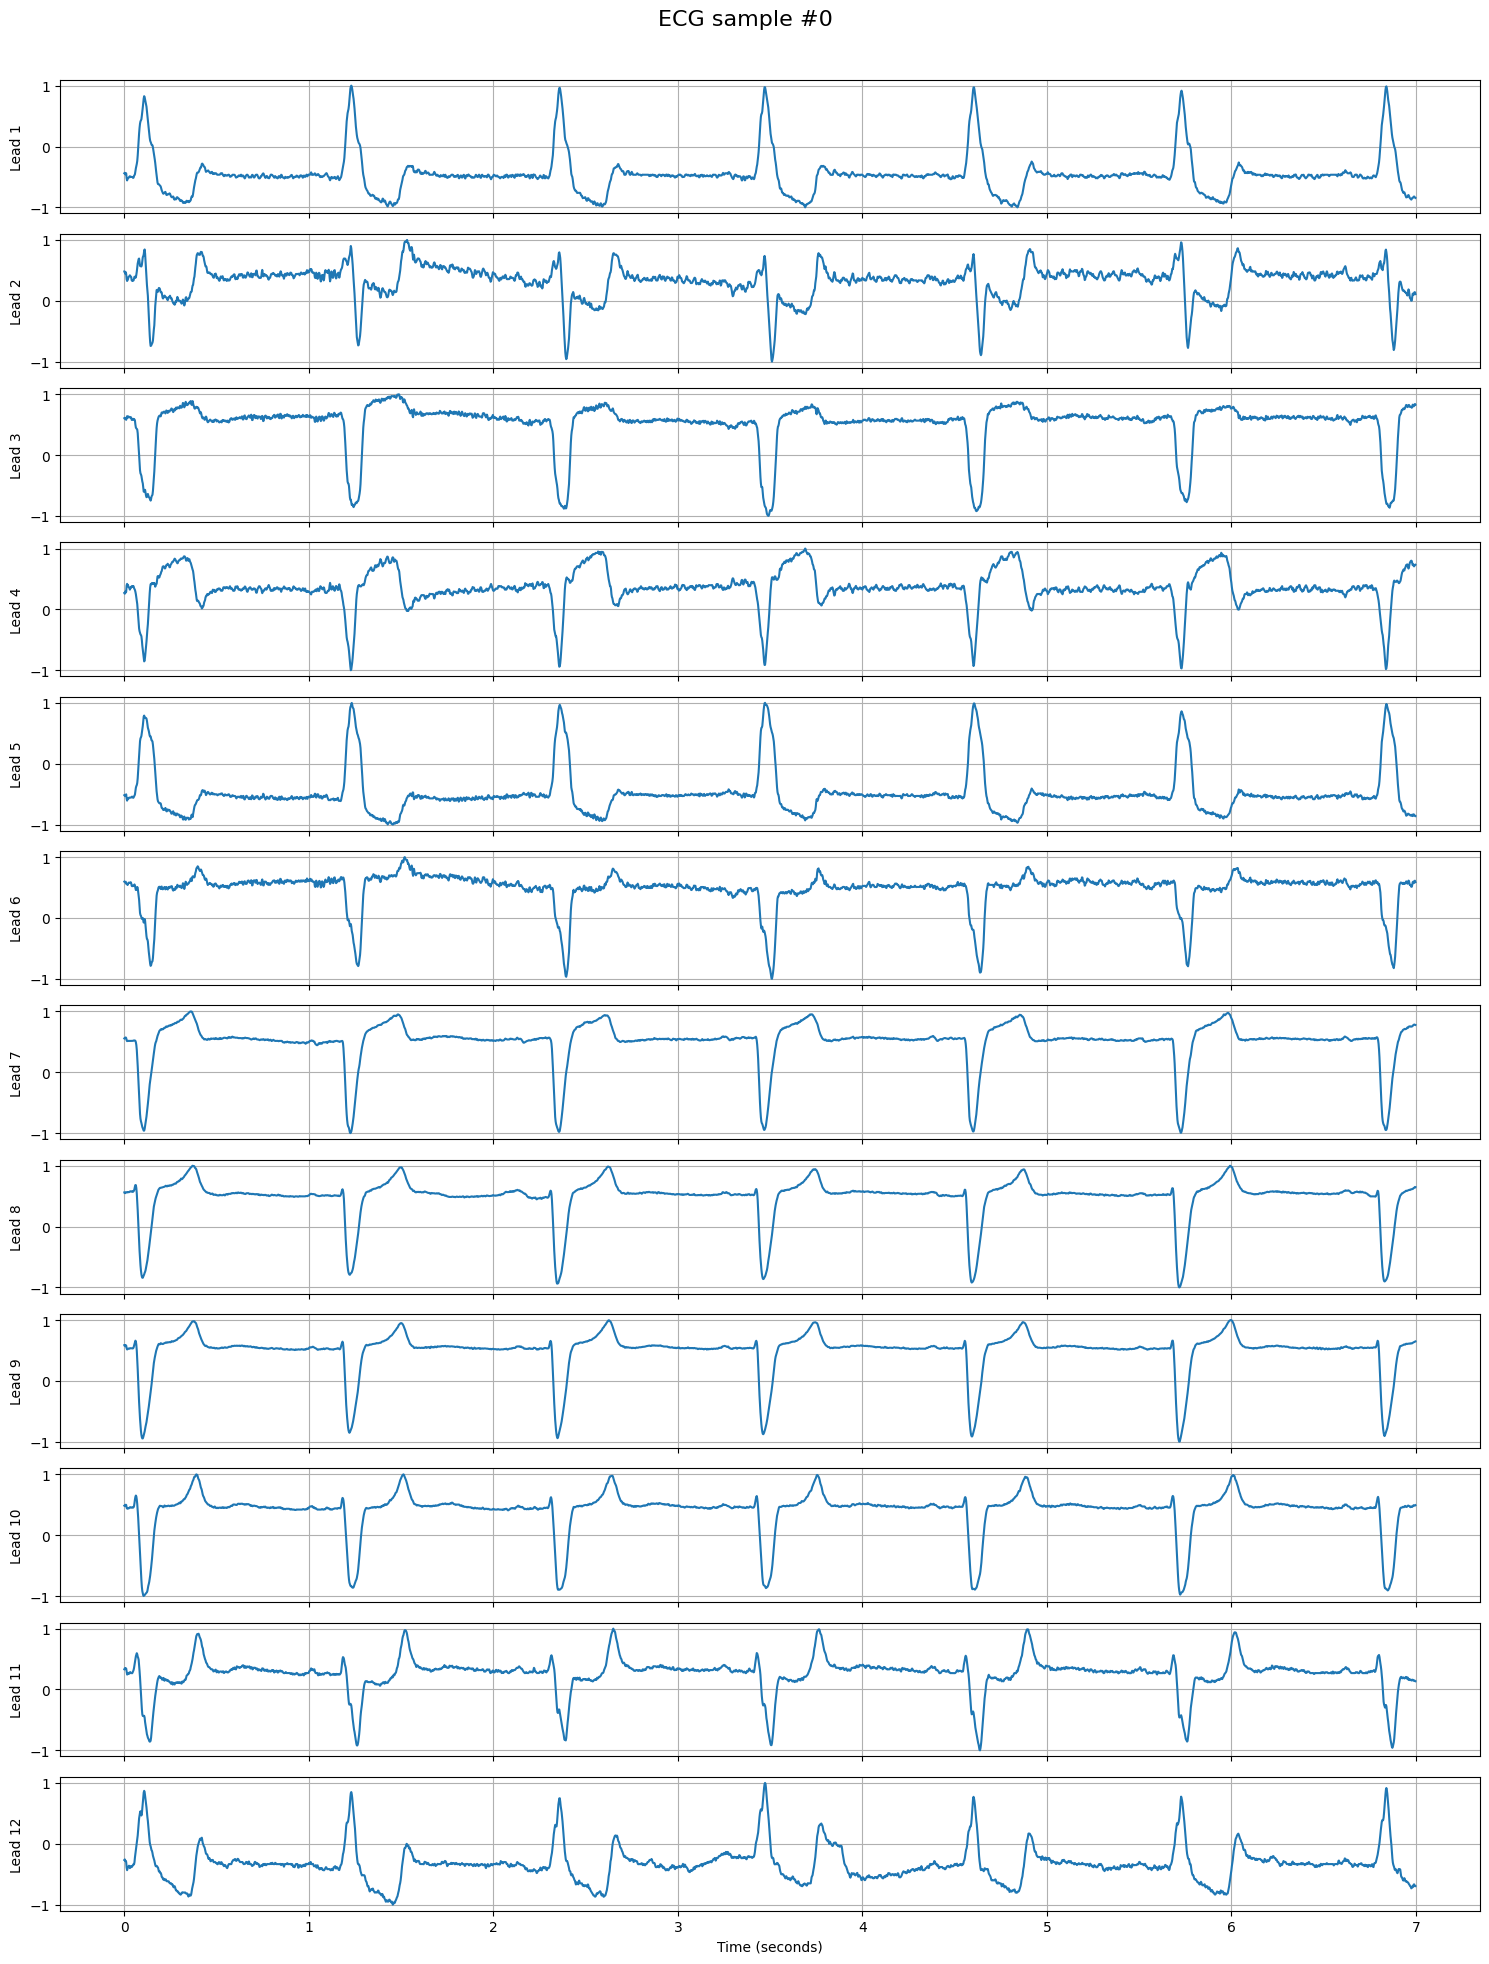

In [6]:
# Configurazione
fs = 400  # frequenza di campionamento
t = np.arange(2800) / fs  # asse temporale in secondi


#Questa prima funzione stampa il grafico di tutte le 12 derivazioni di un campione

def plot_ecg_sample(X, sample_idx=0):
    """Plotta le 12 derivazioni di un segnale ECG specificato da sample_idx."""
    fig, axes = plt.subplots(12, 1, figsize=(15, 20), sharex=True)
    fig.suptitle(f'ECG sample #{sample_idx}', fontsize=16)

    for i in range(12):
        axes[i].plot(t, X[sample_idx, :, i])
        axes[i].set_ylabel(f'Lead {i+1}')
        axes[i].grid(True)

    axes[-1].set_xlabel('Time (seconds)')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# Visualizza i primi 3 segnali a titolo di esempio
for idx in range(1):
    plot_ecg_sample(X, sample_idx=idx)


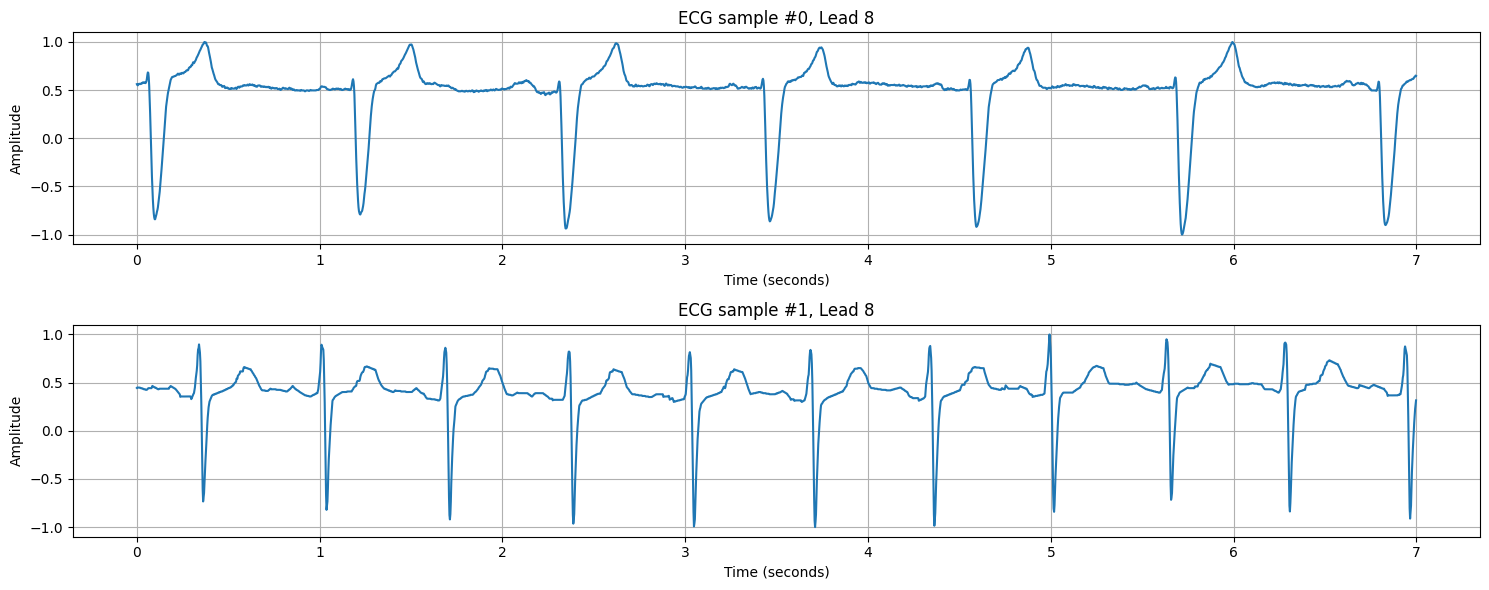

In [7]:
#Questa seconda funzione stampa un numero indicato di esempi di campione sulla stessa derivazione

def plot_ecg_lead(X, samples=5, lead_idx=0):
    """
    Plotta la stessa derivazione (lead) per più segnali campione consecutivi.

    Args:
      X : np.array, shape (n_samples, n_timesteps, n_leads)
      samples : int, quanti campioni mostrare (da 0 a samples-1)
      lead_idx : int, indice della derivazione (0-based)
    """
    n_samples = X.shape[0]
    if samples > n_samples:
        raise ValueError(f"samples è maggiore del numero di segnali disponibili ({n_samples})")
    if lead_idx < 0 or lead_idx >= X.shape[2]:
        raise ValueError(f"lead_idx fuori range: deve essere tra 0 e {X.shape[2]-1}")

    plt.figure(figsize=(15, 3 * samples))
    for i in range(samples):
        plt.subplot(samples, 1, i + 1)
        plt.plot(t, X[i, :, lead_idx])
        plt.title(f'ECG sample #{i}, Lead {lead_idx + 1}')
        plt.xlabel('Time (seconds)')
        plt.ylabel('Amplitude')
        plt.grid(True)
    plt.tight_layout()
    plt.show()

# Esempio d’uso: mostra i primi 5 segnali per la derivazione 7 (indice 6 se zero-based)
plot_ecg_lead(X, samples=2, lead_idx=7)

In [8]:
#SPLIT DEL DATASET
from sklearn.model_selection import train_test_split

# Prima train+val / test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Poi train / val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)
# 0.25 * 0.8 = 0.2 del totale -> val 20%, train 60%

# Modello CNN
Costruiamo e addestriamo un modello con le CNN. Questo tipo di modello è in gradi di apprendere molto bene pattern locali

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn_ecg_model(input_shape=(2800, 12), dropout_rate=0.3):
    inputs = layers.Input(shape=input_shape)

    # Conv Block 1
    x = layers.Conv1D(filters=32, kernel_size=7, strides=1, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Conv Block 2
    x = layers.Conv1D(filters=64, kernel_size=5, strides=1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(dropout_rate)(x)

    # Conv Block 3
    x = layers.Conv1D(filters=128, kernel_size=3, strides=1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(dropout_rate)(x)

    # Conv Block 4
    x = layers.Conv1D(filters=256, kernel_size=3, strides=1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling1D()(x)

    # Fully Connected
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    return model

In [5]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

print(np.unique(y_train))


NameError: name 'y_train' is not defined

In [17]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.metrics import AUC
from sklearn.utils import class_weight
import numpy as np


# ⚙️ Costruzione del modello
model = build_cnn_ecg_model()

# ⚠️ Definizione focal loss
def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_factor = y_true * alpha + (1 - y_true) * (1 - alpha)
        modulating_factor = tf.pow((1 - p_t), gamma)
        return tf.reduce_mean(alpha_factor * modulating_factor * bce)
    return focal_loss_fixed


# ✅ Compilazione del modello
model.compile(optimizer='adam',
              loss=focal_loss(),
              metrics=['accuracy', AUC(name='auc')])

# 🧮 Calcolo pesi di classe
cw = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: cw[0], 1: cw[1]}

# 🛑 Callback: early stopping + reduce LR
early_stop = EarlyStopping(monitor='val_auc', patience=5, mode='max', restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=3, mode='max')

checkpoint = ModelCheckpoint("best_model.h5",
                             monitor='val_auc',
                             mode='max',
                             save_best_only=True,
                             verbose=1)

# 🚀 Addestramento
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=30,
                    batch_size=32,
                    class_weight=class_weights,
                    callbacks=[early_stop, reduce_lr, checkpoint])

Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.7327 - auc: 0.7050 - loss: 0.0436
Epoch 1: val_auc improved from -inf to 0.73833, saving model to best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 87s 606ms/step - accuracy: 0.7328 - auc: 0.7051 - loss: 0.0436 - val_accuracy: 0.7342 - val_auc: 0.7383 - val_loss: 0.0337 - learning_rate: 0.0010
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.7590 - auc: 0.7445 - loss: 0.0348
Epoch 2: val_auc improved from 0.73833 to 0.73951, saving model to best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 81s 597ms/step - accuracy: 0.7589 - auc: 0.7444 - loss: 0.0348 - val_accuracy: 0.7637 - val_auc: 0.7395 - val_loss: 0.0333 - learning_rate: 0.0010
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.7546 - auc: 0.7568 - loss: 0.0339
Epoch 3: val_auc improved from 0.73951 to 0.76068, saving model to best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 82s 611ms/step - accuracy: 0.7546 - auc: 0.7567 - loss: 0.0339 - val_accuracy: 0.7686 - val_auc: 0.7607 - val_loss: 0.0320 - learning_rate: 0.0010
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.7666 - auc: 0.7648 - loss: 0.0324
Epoch 4: val_auc improved from 0.76068 to 0.78518, saving model to best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 82s 616ms/step - accuracy: 0.7666 - auc: 0.7648 - loss: 0.0324 - val_accuracy: 0.7511 - val_auc: 0.7852 - val_loss: 0.0301 - learning_rate: 0.0010
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.7739 - auc: 0.8014 - loss: 0.0292
Epoch 5: val_auc improved from 0.78518 to 0.79525, saving model to best_model.h5


...

134/134 ━━━━━━━━━━━━━━━━━━━━ 82s 603ms/step - accuracy: 0.8735 - auc: 0.9573 - loss: 0.0086 - val_accuracy: 0.8506 - val_auc: 0.9394 - val_loss: 0.0131 - learning_rate: 0.0010
Epoch 21/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.8717 - auc: 0.9560 - loss: 0.0097
Epoch 21: val_auc improved from 0.93943 to 0.94501, saving model to best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 80s 598ms/step - accuracy: 0.8716 - auc: 0.9559 - loss: 0.0097 - val_accuracy: 0.8408 - val_auc: 0.9450 - val_loss: 0.0119 - learning_rate: 0.0010
Epoch 22/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.8756 - auc: 0.9505 - loss: 0.0105
Epoch 22: val_auc improved from 0.94501 to 0.94906, saving model to best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 81s 590ms/step - accuracy: 0.8755 - auc: 0.9505 - loss: 0.0105 - val_accuracy: 0.8738 - val_auc: 0.9491 - val_loss: 0.0139 - learning_rate: 0.0010
Epoch 23/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.8835 - auc: 0.9546 - loss: 0.0101
Epoch 23: val_auc did not improve from 0.94906
134/134 ━━━━━━━━━━━━━━━━━━━━ 84s 630ms/step - accuracy: 0.8834 - auc: 0.9546 - loss: 0.0101 - val_accuracy: 0.8352 - val_auc: 0.9335 - val_loss: 0.0136 - learning_rate: 0.0010
Epoch 24/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.8770 - auc: 0.9560 - loss: 0.0090
Epoch 24: val_auc did not improve from 0.94906
134/134 ━━━━━━━━━━━━━━━━━━━━ 136s 587ms/step - accuracy: 0.8770 - auc: 0.9560 - loss: 0.0090 - val_accuracy: 0.8633 - val_auc: 0.9456 - val_loss: 0.0121 - learning_rate: 0.0010
Epoch 25/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.8806 - auc: 0.9637 - loss: 0.0080
Epoch 25: val_auc did not improve from 0.94906
134/134 ━━━━━━━━━━━━━

134/134 ━━━━━━━━━━━━━━━━━━━━ 84s 599ms/step - accuracy: 0.8854 - auc: 0.9657 - loss: 0.0075 - val_accuracy: 0.8703 - val_auc: 0.9524 - val_loss: 0.0108 - learning_rate: 5.0000e-04
Epoch 27/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.8941 - auc: 0.9698 - loss: 0.0064
Epoch 27: val_auc improved from 0.95242 to 0.95265, saving model to best_model.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 82s 601ms/step - accuracy: 0.8941 - auc: 0.9698 - loss: 0.0064 - val_accuracy: 0.8724 - val_auc: 0.9526 - val_loss: 0.0134 - learning_rate: 5.0000e-04
Epoch 28/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.9045 - auc: 0.9732 - loss: 0.0060
Epoch 28: val_auc did not improve from 0.95265
134/134 ━━━━━━━━━━━━━━━━━━━━ 79s 592ms/step - accuracy: 0.9044 - auc: 0.9732 - loss: 0.0060 - val_accuracy: 0.8647 - val_auc: 0.9501 - val_loss: 0.0112 - learning_rate: 5.0000e-04
Epoch 29/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.9002 - auc: 0.9704 - loss: 0.0064
Epoch 29: val_auc did not improve from 0.95265
134/134 ━━━━━━━━━━━━━━━━━━━━ 82s 592ms/step - accuracy: 0.9002 - auc: 0.9704 - loss: 0.0064 - val_accuracy: 0.8569 - val_auc: 0.9451 - val_loss: 0.0127 - learning_rate: 5.0000e-04
Epoch 30/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.9055 - auc: 0.9739 - loss: 0.0058
Epoch 30: val_auc did not improve from 0.95265
134/134 ━━

In [19]:
#Salvo una copia del modello addestrato su drive
!cp best_model.h5 /content/drive/MyDrive/chagas_models/CNN_best_model.h5

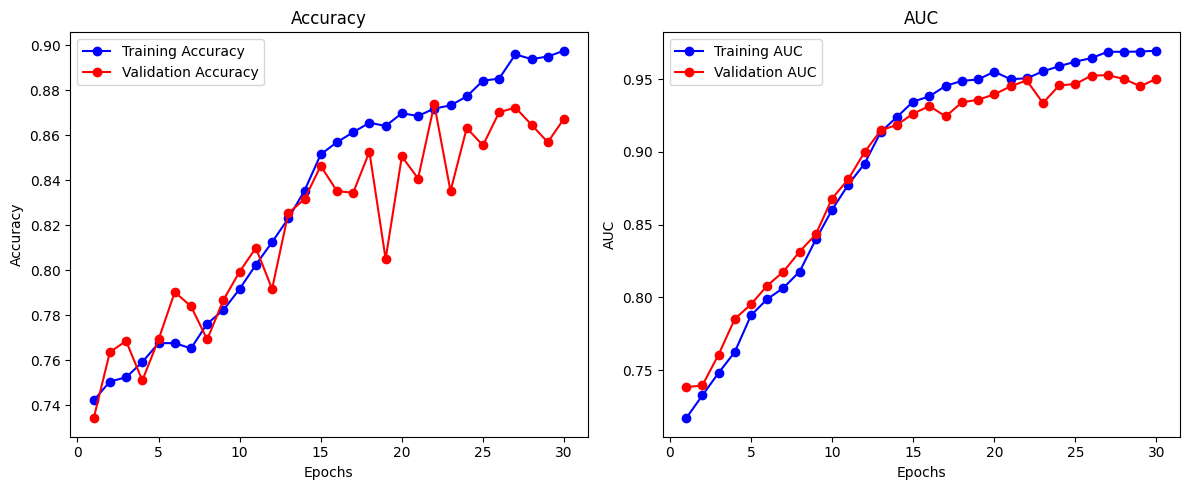

In [20]:
import matplotlib.pyplot as plt

# Estrai le metriche salvate durante l'addestramento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
auc = history.history['auc']
val_auc = history.history['val_auc']
epochs = range(1, len(acc) + 1)

# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot AUC
plt.subplot(1, 2, 2)
plt.plot(epochs, auc, 'bo-', label='Training AUC')
plt.plot(epochs, val_auc, 'ro-', label='Validation AUC')
plt.title('AUC')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()


In [21]:
from sklearn.metrics import roc_curve

# y_pred_proba: predizioni probabilistiche (es. model.predict(X_test))
y_pred_proba = model.predict(X_test).flatten()

# Calcola curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Soglia ottimale = massimizza TPR - FPR
optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]
print(f"Soglia ottimale: {optimal_threshold:.3f}")

# Applica soglia ottimale per binarizzare le predizioni
y_pred_binary = (y_pred_proba >= optimal_threshold).astype(int)


45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step
Soglia ottimale: 0.291


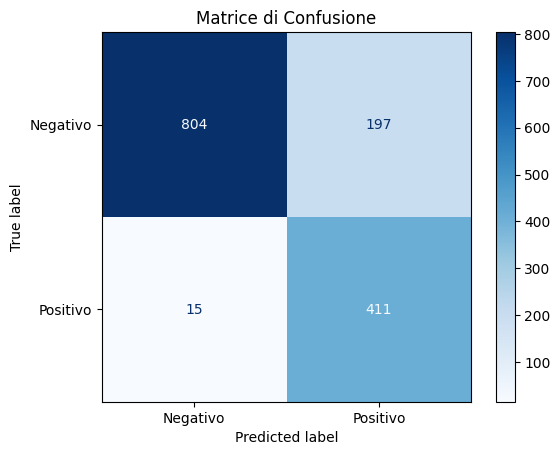

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_binary)

# Visualizza la matrice
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negativo", "Positivo"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice di Confusione")
plt.show()

# Valutiamo le metriche

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report

acc = accuracy_score(y_test, y_pred_binary)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {acc:.3f}")
print(f"AUC: {auc:.3f}")

print(classification_report(y_test, y_pred_binary, target_names=["Negativo", "Positivo"]))

Accuracy: 0.851
AUC: 0.948


              precision    recall  f1-score   support

    Negativo       0.98      0.80      0.88      1001
    Positivo       0.68      0.96      0.79       426

    accuracy                           0.85      1427
   macro avg       0.83      0.88      0.84      1427
weighted avg       0.89      0.85      0.86      1427